# Multi-Model Switching with Contact


## Goal
Demonstrate runtime switching between pendulum models (FMU/OpenSim/FEM) during contact and evaluate the resulting trajectory.

## Model Map
- `SineAngleSetPoint` → `PIDContinuous` → `DriveDynamic` → `MasterPendulum`
- Measurement path: `MasterPendulum.theta` → `AnglePotentiometerADC` → `AnglePotentiometerADCDecoder` → `PIDContinuous`
- Contact events trigger velocity inversion and optional PID reset

## Assumptions and Scope
- Contact modeled as discrete events
- Fixed-step co-simulation

## Baseline Parameters
Shared defaults from the Modelica models; used unless explicitly overridden.

In [14]:
import numpy as np

baseline_params = {
    "trajectory": {
        "offset_rad": 0.0,
        "amplitude_rad": np.pi / 9,
        "frequency_hz": 0.25,
        "phase_rad": 0.0,
        "start_time_s": 0.0,
    },
    "pid": {
        "kp": 20,
        "ki": 5,
        "kd": 0.01,
        "td": 0.6,
        "nd": 10,
        "u_min": -1,
        "u_max": 1,
    },
    "sensor": {
        "nBits": 12,
        "samplePeriod": 0.005,
    },
    "fem": {
        "dt": 0.001,
        "t_end": 5.0,
        "with_contact": True,
        "use_gravity": True,
    },
}

baseline_params


{'trajectory': {'offset_rad': 0.0,
  'amplitude_rad': 0.3490658503988659,
  'frequency_hz': 0.25,
  'phase_rad': 0.0,
  'start_time_s': 0.0},
 'pid': {'kp': 20,
  'ki': 5,
  'kd': 0.01,
  'td': 0.6,
  'nd': 10,
  'u_min': -1,
  'u_max': 1},
 'sensor': {'nBits': 12, 'samplePeriod': 0.005},
 'fem': {'dt': 0.001, 't_end': 5.0, 'with_contact': True, 'use_gravity': True}}

## Prerequisites and Setup

In [15]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config
from syssimx import FMUComponent, System, SystemGraphVisualizer, Connection, EventConnection


## Discover FMUs

In [16]:
PLATFORM = sys.platform
demo_dir_path = Path().cwd() / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir


## Instantiate FMU Components

In [17]:
set_point = FMUComponent(name="SetPoint", fmu_path=fmu_paths['Trajectories']["SineAngleSetPoint"], group="Controller")
drive = FMUComponent(name="Drive", fmu_path=fmu_paths['Actuators']["DriveDynamic"], group="Actuator")

angle_encoder = FMUComponent(name="Angle Sensor", fmu_path=fmu_paths['Sensors']['AnglePotentiometerADC'], group="Sensor")
angle_decoder = FMUComponent(name="Decoder", fmu_path=fmu_paths['Sensors']['AnglePotentiometerADCDecoder'], group="Controller")


## Apply Baseline Parameters

In [18]:
set_point.set_parameters(
    offset=baseline_params["trajectory"]["offset_rad"],
    amplitude=baseline_params["trajectory"]["amplitude_rad"],
    frequency=baseline_params["trajectory"]["frequency_hz"],
    phase=baseline_params["trajectory"]["phase_rad"],
    startTime=baseline_params["trajectory"]["start_time_s"],
)

angle_encoder.set_parameters(
    nBits=baseline_params["sensor"]["nBits"],
    samplePeriod=baseline_params["sensor"]["samplePeriod"],
)
angle_decoder.set_parameters(
    nBits=baseline_params["sensor"]["nBits"],
    samplePeriod=baseline_params["sensor"]["samplePeriod"],
)


## PID with Contact Reset (Optional)

In [19]:
class PIDController(FMUComponent):
    def __init__(self, name):
        fmu_path = fmu_paths['Controllers']['PIDContinuous_euler']
        super().__init__(name=name, fmu_path=fmu_path, group="Controller")
    
    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0)
        self.set_inputs({"resetI": False})

pid = PIDController(name="PID")

pid.set_parameters(
    Kp=baseline_params["pid"]["kp"],
    Ki=baseline_params["pid"]["ki"],
    Kd=baseline_params["pid"]["kd"],
    Td=baseline_params["pid"]["td"],
    Nd=baseline_params["pid"]["nd"],
    uMin=baseline_params["pid"]["u_min"],
    uMax=baseline_params["pid"]["u_max"],
)


## Configure `MasterPendulum`

In [20]:
init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 0

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11
mat_params.nu_pendulum = 0.3
mat_params.rho_pendulum = 7800

sim_params = config.SimulationParameters()
sim_params.tau = baseline_params["fem"]["dt"]
sim_params.t_end = baseline_params["fem"]["t_end"]
sim_params.with_contact = baseline_params["fem"]["with_contact"]
sim_params.use_gravity = baseline_params["fem"]["use_gravity"]

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'mat_params': mat_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")
pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


## Contact Event Indicator

In [21]:
def wall_contact_indicator(comp: MasterPendulum) -> float:
    theta = comp.get_outputs()["theta"]
    theta_wall = 0.0
    return theta - theta_wall

pendulum.add_event_indicator("wall_hit", func=wall_contact_indicator, direction=-1)


## Define Connections

In [22]:
c1 = Connection(set_point.name, set_point.output_specs["theta_ref"].name, pid.name, pid.input_specs["theta_ref"].name)

c2 = Connection(pendulum.name, pendulum.output_specs["theta"].name, angle_encoder.name, angle_encoder.input_specs["theta"].name)

c3 = Connection(angle_encoder.name, angle_encoder.output_specs["v_out"].name, angle_decoder.name, angle_decoder.input_specs["v_in"].name)

c4 = Connection(angle_decoder.name, angle_decoder.output_specs["theta"].name, pid.name, pid.input_specs["theta_meas"].name)

c5 = Connection(pid.name, pid.output_specs["u"].name, drive.name, drive.input_specs["u_control"].name)

c6 = Connection(drive.name, drive.output_specs["torque"].name, pendulum.name, pendulum.input_specs["tau"].name)

c7 = Connection(pendulum.name, pendulum.output_specs["omega"].name, drive.name, drive.input_specs["omega"].name)

connections = [c1, c2, c3, c4, c5, c6, c7]
components  = [set_point, pid, drive, pendulum, angle_decoder, angle_encoder]


## Event Connections

In [23]:
event_connection_1 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["omega_invert"].name,
)

event_connection_2 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pid.name,
    dst_port=pid.input_specs["resetI"].name,
)

event_connections = [event_connection_1, event_connection_2]


## Build and Initialize the System

In [24]:
system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

for event_conn in event_connections:
    system.add_event_connection(event_conn)

system.initialize(t0=0.0)


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


## Visualize the System Graph

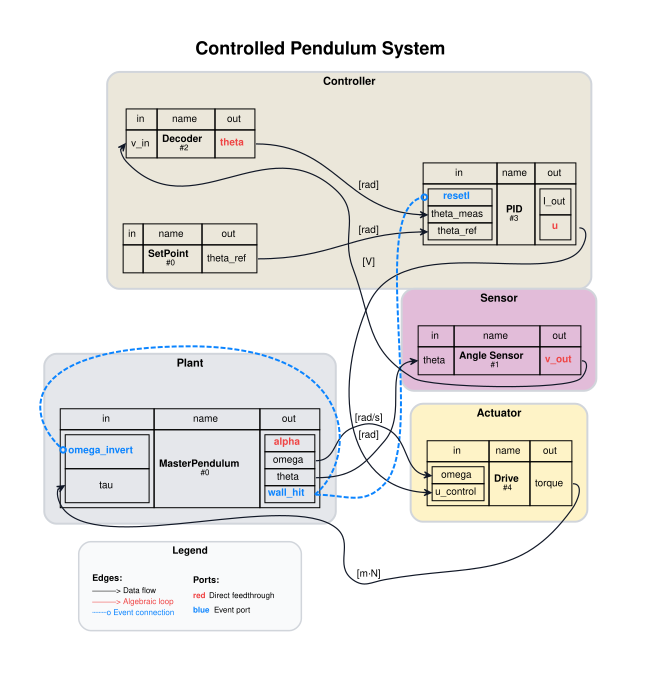

In [25]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()


## Setup Pendulum Monitoring

In [26]:
pendulum.setup_monitoring()
pendulum.display_monitoring()


HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

## Run Simulation

In [ ]:
t = 0.0
dt = sim_params.tau
t_end = sim_params.t_end

system.run(t, t_end, dt)

print(f"Simulation config → dt [s]: {dt}, t_end [s]: {t_end}, contact: {sim_params.with_contact}")


## Save Results (Optional)

In [ ]:
system_res_file = Path.cwd() / "demos/ControlledPendulum/artifacts/results/contact_history.csv"
system_res_file.parent.mkdir(parents=True, exist_ok=True)
system.history.save_csv(filepath=system_res_file)
print(f"Saved results to: {system_res_file}")


## Collect Results

In [ ]:
fem_hist = pendulum.fem.get_history()
fmu_hist = pendulum.fmu.get_history()
opensim_hist = pendulum.opensim.get_history()

t_fem = fem_hist['theta']['time']
theta_fem = fem_hist['theta']['values']
t_fmu = fmu_hist['theta']['time']
theta_fmu = fmu_hist['theta']['values']
t_opensim = opensim_hist['theta']['time']
theta_opensim = opensim_hist['theta']['values']

history = system.get_history()

ref_history = history["SetPoint"]
setpoint_time, data = ref_history
theta_ref = data["theta_ref"]


## Plot Styles

In [ ]:
marker_size = 3
palette = {
    "fem": "#1f77b4",
    "opensim": "#ff7f0e",
    "fmu": "#2ca02c",
    "setpoint": "#d62728",
}

fem_style = {
    "color": palette["fem"],
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 2.5,
}
opensim_style = {
    "color": palette["opensim"],
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 2.5,
}
fmu_style = {
    "color": palette["fmu"],
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 2.5,
}


## Plot: Multi-Model Switching
This plot overlays all three sub-models and the setpoint.

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t_fem, theta_fem, label="FEM Pendulum", **fem_style)
plt.plot(t_opensim, theta_opensim, label="OpenSim Pendulum", **opensim_style)
plt.plot(t_fmu, theta_fmu, label="FMU Pendulum", **fmu_style)
plt.plot(setpoint_time, theta_ref, label="Setpoint", color=palette["setpoint"], linestyle="--", linewidth=1.5)
plt.axvspan(1.95, 2.2, color="#9467bd", alpha=0.2)
plt.axvspan(3.8, 4.05, color="#ffbb78", alpha=0.2)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Angular Position $\theta$  [rad]")
plt.title("Master Pendulum: Model Switching During Contact")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Plot: Contact Windows
Zoom into the two contact phases for FEM response.

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t_fem, theta_fem, label="FEM Pendulum", **{**fem_style, "markersize": 2})
plt.plot(setpoint_time, theta_ref, label="Setpoint", color=palette["setpoint"], linestyle="--", linewidth=1.2)
plt.axhline(0.0, color="#7f7f7f", linestyle="--", linewidth=1)
plt.axvspan(1.95, 2.2, color="#9467bd", alpha=0.2)
plt.xlim(1.95, 2.2)
plt.ylim(-0.0005, 0.01)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Angular Position $\theta$  [rad]")
plt.title("Contact Phase Start (Zoom)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t_fem, theta_fem, label="FEM Pendulum", **{**fem_style, "markersize": 2})
plt.plot(setpoint_time, theta_ref, label="Setpoint", color=palette["setpoint"], linestyle="--", linewidth=1.2)
plt.axhline(0.0, color="#7f7f7f", linestyle="--", linewidth=1)
plt.axvspan(3.8, 4.05, color="#ffbb78", alpha=0.2)
plt.xlim(3.8, 4.05)
plt.ylim(-0.0005, 0.01)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Angular Position $\theta$  [rad]")
plt.title("Contact Phase End (Zoom)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Plot: PID Integrator Output
Inspect integrator behavior around contact events.

In [ ]:
pid_hist = history['PID']
t_pid, data_pid = pid_hist
i_out = data_pid.get('I_out', None)

if i_out is not None:
    plt.figure(figsize=(10, 6))
    plt.plot(t_pid, i_out, label="PID I_out", color="#9467bd", linestyle="-")
    plt.axhline(0.0, color="#7f7f7f", linestyle="--", linewidth=1)
    plt.xlabel(r"Time $t$  [s]")
    plt.ylabel(r"PID Integrator Output $I_{out}$  [–]")
    plt.title("PID Integrator Output")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## Summary
- The MasterPendulum switches between FMU, OpenSim, and FEM based on contact events.
- Contact windows show the high-resolution FEM response while the global response stays consistent.